In [ ]:

!pip install git+https://github.com/openai/CLIP.git
!pip install transformers

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-7dz7_49t
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-7dz7_49t
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=74879e4b5035d381e9c37ebfec37d32eda25e337a77defcc5f49080f2f2accad
  Stored in directory: /tmp/pip-ephem-wheel-cache-4djn8yg9/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
import clip
import torch
from PIL import Image
import requests
from io import BytesIO


device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

print(f"Model loaded on: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 77.0MiB/s]


Model loaded on: cpu
Model parameters: 151,277,313



📊 CLIP Similarity Scores (clip-vit-base-patch32):

Text Description                                 Score
-------------------------------------------------------
a dog and its owner posing                    0.5543
a man playing with his pet                    0.2372
a human and animal together                   0.1162
a dog sitting next to a human                 0.0661
a man walking with a dog                      0.0183
a person and a dog outdoors                   0.0077
a woman holding a baby                        0.0002
two dogs playing in a field                   0.0001
a cat sitting on a bench                      0.0001
a dog running in a park                       0.0000


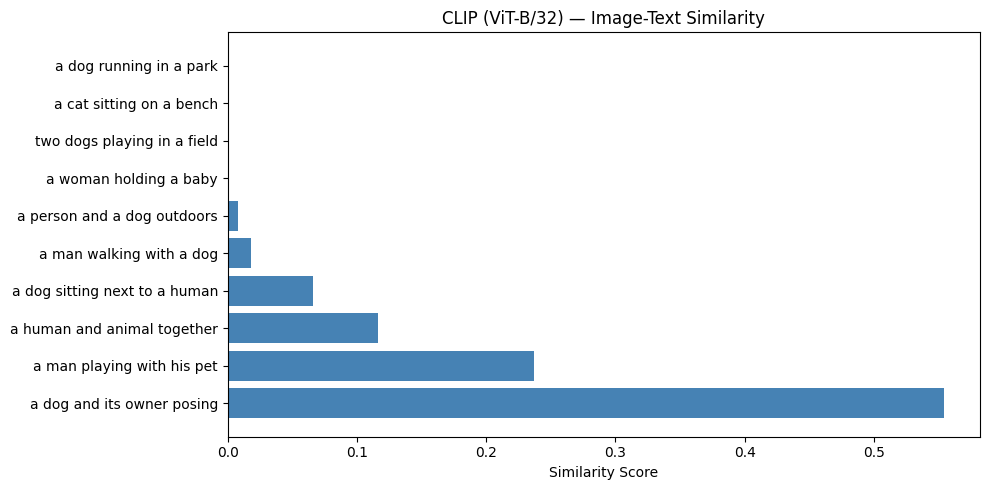

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/sample_image.jpg"
image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)

texts = ["a man walking with a dog","a person and a dog outdoors","a dog sitting next to a human","a man playing with his pet","a dog running in a park","a cat sitting on a bench", "a woman holding a baby",
    "a dog and its owner posing",
    "a human and animal together",
    "two dogs playing in a field"]


text_tokens = clip.tokenize(texts).to(device)

with torch.no_grad():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text_tokens)


    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    similarity = similarity.cpu().numpy()[0]


print("\nCLIP Similarity Score (clip-vit-base-patch32):\n")
print(f"{'Text Description':<45} {'Score':>8}")
for text, score in sorted(zip(texts, similarity), key=lambda x: -x[1]):
    print(f"{text:<45} {score:.4f}")

plt.figure(figsize=(10, 5))
sorted_pairs = sorted(zip(texts, similarity), key=lambda x: -x[1])
labels, scores = zip(*sorted_pairs)
plt.barh(labels, scores, color='steelblue')
plt.xlabel("Similarity Score")
plt.title("CLIP (ViT-B/32) ImageText Similarity")
plt.tight_layout()
plt.savefig("clip_similarity.png", dpi=150)
plt.show()

In [ ]:

!pip install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.3 MB/s eta 0:00:00


In [ ]:
from open_clip import create_model_from_pretrained, get_tokenizer

clips_model, clips_preprocess = create_model_from_pretrained('hf-hub:UCSC-VLAA/ViT-L-14-CLIPS-Recap-DataComp-1B')
clips_tokenizer = get_tokenizer('hf-hub:UCSC-VLAA/ViT-L-14-CLIPS-Recap-DataComp-1B')
clips_model = clips_model.to(device).eval()
print("CLIPS model loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_config.json:   0%|          | 0.00/943 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/1.66G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

CLIPS model loaded!


In [ ]:
import torch.nn.functional as F

clips_image = clips_preprocess(Image.open(image_path)).unsqueeze(0).to(device)

clips_text_tokens = clips_tokenizer(texts, context_length=clips_model.context_length).to(device)

with torch.no_grad(), torch.cuda.amp.autocast():
    clips_image_features = clips_model.encode_image(clips_image)
    clips_text_features = clips_model.encode_text(clips_text_tokens)

    clips_image_features = F.normalize(clips_image_features, dim=-1)
    clips_text_features = F.normalize(clips_text_features, dim=-1)

    clips_similarity = (100.0 * clips_image_features @ clips_text_features.T).softmax(dim=-1)
    clips_similarity = clips_similarity.cpu().numpy()[0]

print("\n CLIPS similarity Scores (ViT-L/14):\n")
print(f"{'Text Description':<45} {'Score':>8}")
for text, score in sorted(zip(texts, clips_similarity), key=lambda x: -x[1]):
    print(f"{text:<45} {score:.4f}")

/tmp/ipykernel_10123/1068965776.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(



📊 CLIPS Similarity Scores (ViT-L/14):

Text Description                                 Score
-------------------------------------------------------
a dog and its owner posing                    0.8256
a man playing with his pet                    0.1436
a dog sitting next to a human                 0.0134
a man walking with a dog                      0.0111
a human and animal together                   0.0051
a person and a dog outdoors                   0.0009
two dogs playing in a field                   0.0001
a woman holding a baby                        0.0001
a dog running in a park                       0.0000
a cat sitting on a bench                      0.0000


In [ ]:
import pandas as pd


df = pd.DataFrame({"Description": texts,"CLIP Score": similarity,"CLIPS Score": clips_similarity}).sort_values("CLIP Score", ascending=False).reset_index(drop=True)

print(df.to_string(index=False))

x = np.arange(len(texts))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(x - width/2, df["CLIP Score"], width, label='CLIP ViT-B/32', color='steelblue')
ax.barh(x + width/2, df["CLIPS Score"], width, label='CLIPS ViT-L/14', color='coral')
ax.set_yticks(x)
ax.set_yticklabels(df["Description"], fontsize=9)
ax.set_xlabel("Similarity Score")
ax.set_title("CLIP vs CLIPS Similarity Score Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("clip_vs_clips.png", dpi=150)
plt.show()

ValueError: Mixing dicts with non-Series may lead to ambiguous ordering.

In [ ]:
# Q2 ------- 
!pip install transformers -q

from transformers import BlipProcessor, BlipForQuestionAnswering
from PIL import Image
import torch

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
blip_model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to(device)

print("BLIP VQA model loaded!")

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BLIP VQA model loaded!


In [ ]:
def blipvqa(image_path, question):
    raw_image = Image.open(image_path).convert("RGB")
    inputs = blip_processor(raw_image, question, return_tensors="pt").to(device)
    with torch.no_grad():
        out = blip_model.generate(**inputs)
    return blip_processor.decode(out[0], skip_special_tokens=True)


ans = blipvqa(image_path, "What is in the image?")
print("Test answer:", ans)

Test answer: man holding dog


In [ ]:
import pandas as pd

dog_questions = ["Where is the dog present in the image?",
    "Can you tell where the dog is located in the picture?",
    "In which part of the image is the dog positioned?",
    "Where is the dog relative to the man in the image?",
    "Describe the location of the dog using context.",
    "What is the dog doing and where is it in the scene?"]

dog_answers=[blipvqa(image_path, q) for q in dog_questions]

dog_df = pd.DataFrame({"Question": dog_questions, "BLIP Answer": dog_answers})
print(dog_df.to_string(index=False))

                                             Question     BLIP Answer
               Where is the dog present in the image? in man ' s arms
Can you tell where the dog is located in the picture?             yes
    In which part of the image is the dog positioned?            back
   Where is the dog relative to the man in the image?          behind
      Describe the location of the dog using context.          behind
  What is the dog doing and where is it in the scene?      being held


In [ ]:
man_question ="Where is the man present in the image?"
man_answer =blipvqa(image_path, man_question)
print(f"Q: {man_question}")
print(f"A: {man_answer}")

Q: Where is the man present in the image?
A: living room


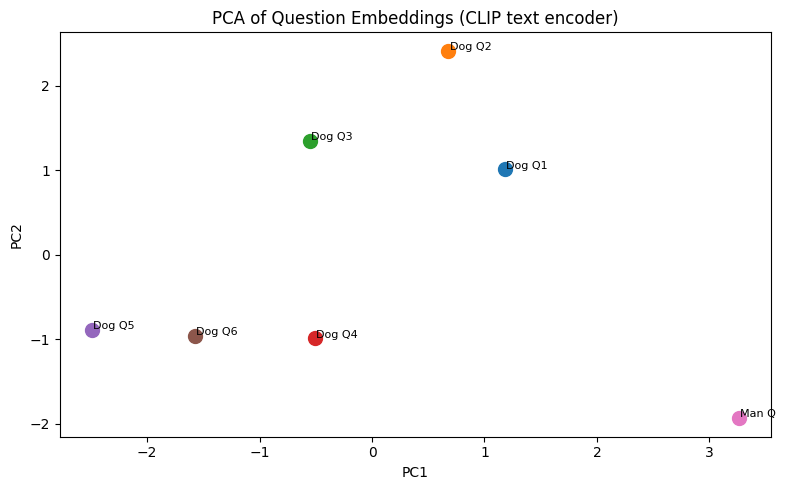

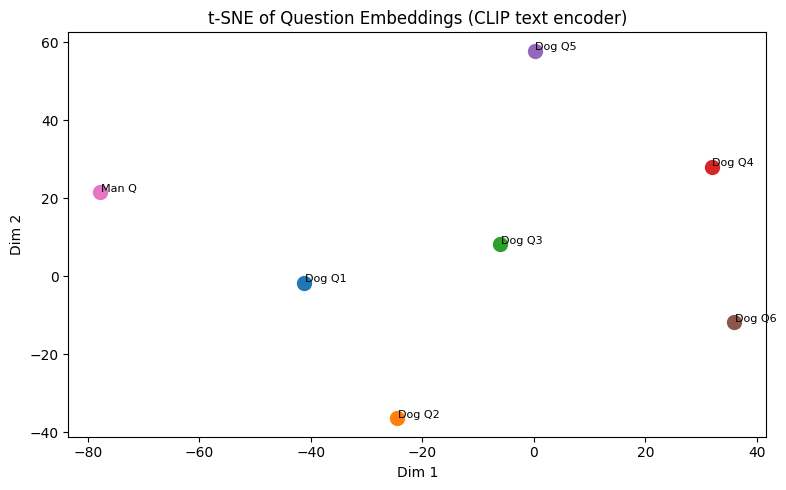

In [ ]:
#pca of question embeddings

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import clip 


all_questions = dog_questions + [man_question]
labels = [f"Dog Q{i+1}" for i in range(len(dog_questions))] + ["Man Q"]

tokens = clip.tokenize(all_questions).to(device)
with torch.no_grad():
    embeddings = model.encode_text(tokens).cpu().numpy()


pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 5))
for i, label in enumerate(labels):
    plt.scatter(pca_result[i, 0], pca_result[i, 1], s=100)
    plt.annotate(label, (pca_result[i, 0]+0.01, pca_result[i, 1]+0.01), fontsize=8)
plt.title("PCA of Question Embeddings (CLIP text encoder)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("pca_questions.png", dpi=150)
plt.show()

tsne = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_result = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 5))
for i, label in enumerate(labels):
    plt.scatter(tsne_result[i, 0], tsne_result[i, 1], s=100)
    plt.annotate(label, (tsne_result[i, 0]+0.1, tsne_result[i, 1]+0.1), fontsize=8)
plt.title("t-SNE of Question Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.tight_layout()
plt.savefig("tsne_questions.png", dpi=150)
plt.show()

In [ ]:
#Q3-------------
from transformers import BlipProcessor, BlipForConditionalGeneration

caption_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
caption_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

print("BLIP Captioning model loaded!")


def gnr_cpt(img_path, conditional_text=None):
    raw_image = Image.open(img_path).convert("RGB")
    if conditional_text:
        inputs = caption_processor(raw_image, conditional_text, return_tensors="pt").to(device)
    else:
        inputs = caption_processor(raw_image, return_tensors="pt").to(device)
    with torch.no_grad():
        out = caption_model.generate(**inputs, max_new_tokens=50)
    return caption_processor.decode(out[0], skip_special_tokens=True)

caption1 = gnr_cpt(image_path)
print(f"\ngenerated Caption: {caption1}")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BLIP Captioning model loaded!


model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]


Generated Caption: a man holding a dog


In [ ]:
import zipfile

with zipfile.ZipFile("/content/sample_images.zip", 'r') as z:
    z.extractall("/content/sample_images/")
import os
print(os.listdir("/content/sample_images/"))

['samples']


In [ ]:
image_names = ["ILSVRC2012_test_00000003.jpg",
    "ILSVRC2012_test_00000004.jpg",
    "ILSVRC2012_test_00000018.jpg",
    "ILSVRC2012_test_00000019.jpg",
    "ILSVRC2012_test_00000022.jpg",
    "ILSVRC2012_test_00000023.jpg",
    "ILSVRC2012_test_00000025.jpg",
    "ILSVRC2012_test_00000026.jpg",
    "ILSVRC2012_test_00000030.jpg",
    "ILSVRC2012_test_00000034.jpg",]

image_paths = [f"/content/sample_images/samples/{name}" for name in image_names]


results = []
for path in image_paths:
    cap = gnr_cpt(path)
    results.append({"Image": os.path.basename(path), "BLIP Caption": cap})
    print(f"✅ {os.path.basename(path)}: {cap}")

caption_df = pd.DataFrame(results)
print("\n", caption_df.to_string(index=False))

✅ ILSVRC2012_test_00000003.jpg: a small dog walking on a green carpet
✅ ILSVRC2012_test_00000004.jpg: a small dog running across a green field
✅ ILSVRC2012_test_00000018.jpg: a family sitting in a pool with a towel
✅ ILSVRC2012_test_00000019.jpg: a small bird sitting on a plant
✅ ILSVRC2012_test_00000022.jpg: a small dog standing on a stone ledge
✅ ILSVRC2012_test_00000023.jpg: a man riding a bike down a wet street
✅ ILSVRC2012_test_00000025.jpg: a brown butterfly sitting on a green plant
✅ ILSVRC2012_test_00000026.jpg: a man in a suit and tie sitting on a couch
✅ ILSVRC2012_test_00000030.jpg: a duck drinking water from a pond
✅ ILSVRC2012_test_00000034.jpg: a coffee machine with two cups on it

                        Image                               BLIP Caption
ILSVRC2012_test_00000003.jpg      a small dog walking on a green carpet
ILSVRC2012_test_00000004.jpg   a small dog running across a green field
ILSVRC2012_test_00000018.jpg    a family sitting in a pool with a towel
ILSVRC

In [ ]:
clip_preprocess = preprocess
import torch.nn.functional as F

def clip_imgtxt_sml(img_path, text):
    
    raw_image = clip_preprocess(Image.open(img_path)).unsqueeze(0).to(device)
    text_token = clip.tokenize([text]).to(device)
    with torch.no_grad():
        img_feat = model.encode_image(raw_image)
        txt_feat = model.encode_text(text_token)
        img_feat = F.normalize(img_feat, dim=-1)
        txt_feat = F.normalize(txt_feat, dim=-1)
        score = (img_feat @ txt_feat.T).item()
    return round(score, 4)

clip_scores = []
for row in results:
    img_name = row["Image"]
    caption = row["BLIP Caption"]
    img_path = [p for p in image_paths if os.path.basename(p) == img_name][0]
    score = clip_imgtxt_sml(img_path, caption)
    clip_scores.append(score)

caption_df["CLIP Score"] = clip_scores
print(caption_df.to_string(index=False))

                       Image                               BLIP Caption  CLIP Score
ILSVRC2012_test_00000003.jpg      a small dog walking on a green carpet      0.3157
ILSVRC2012_test_00000004.jpg   a small dog running across a green field      0.3270
ILSVRC2012_test_00000018.jpg    a family sitting in a pool with a towel      0.3134
ILSVRC2012_test_00000019.jpg            a small bird sitting on a plant      0.2894
ILSVRC2012_test_00000022.jpg      a small dog standing on a stone ledge      0.3103
ILSVRC2012_test_00000023.jpg      a man riding a bike down a wet street      0.3083
ILSVRC2012_test_00000025.jpg a brown butterfly sitting on a green plant      0.2892
ILSVRC2012_test_00000026.jpg a man in a suit and tie sitting on a couch      0.2890
ILSVRC2012_test_00000030.jpg          a duck drinking water from a pond      0.3053
ILSVRC2012_test_00000034.jpg       a coffee machine with two cups on it      0.2796


In [ ]:
def clips_image_text_similarity(img_path, text):
    raw_image = clips_preprocess(Image.open(img_path)).unsqueeze(0).to(device)
    text_token = clips_tokenizer([text], context_length=clips_model.context_length).to(device)
    with torch.no_grad(), torch.cuda.amp.autocast():
        img_feat = clips_model.encode_image(raw_image)
        txt_feat = clips_model.encode_text(text_token)
        img_feat = F.normalize(img_feat, dim=-1)
        txt_feat = F.normalize(txt_feat, dim=-1)
        score = (img_feat @ txt_feat.T).item()
    return round(score, 4)


clips_scores = []
for row in results:
    img_name = row["Image"]
    caption = row["BLIP Caption"]
    img_path = [p for p in image_paths if os.path.basename(p) == img_name][0]
    score = clips_image_text_similarity(img_path, caption)
    clips_scores.append(score)

caption_df["CLIPS Score"] = clips_scores

print(caption_df[["Image", "BLIP Caption", "CLIP Score", "CLIPS Score"]].to_string(index=False))

/tmp/ipykernel_10123/3423174989.py:5: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(


                       Image                               BLIP Caption  CLIP Score  CLIPS Score
ILSVRC2012_test_00000003.jpg      a small dog walking on a green carpet      0.3157       0.1955
ILSVRC2012_test_00000004.jpg   a small dog running across a green field      0.3270       0.2010
ILSVRC2012_test_00000018.jpg    a family sitting in a pool with a towel      0.3134       0.1495
ILSVRC2012_test_00000019.jpg            a small bird sitting on a plant      0.2894       0.1740
ILSVRC2012_test_00000022.jpg      a small dog standing on a stone ledge      0.3103       0.1528
ILSVRC2012_test_00000023.jpg      a man riding a bike down a wet street      0.3083       0.1668
ILSVRC2012_test_00000025.jpg a brown butterfly sitting on a green plant      0.2892       0.1743
ILSVRC2012_test_00000026.jpg a man in a suit and tie sitting on a couch      0.2890       0.1287
ILSVRC2012_test_00000030.jpg          a duck drinking water from a pond      0.3053       0.1728
ILSVRC2012_test_00000034.jpg  

In [ ]:
import numpy as np

def get_txtemb(text):
    token = clip.tokenize([text]).to(device)
    with torch.no_grad():
        feat = model.encode_text(token)
        feat = F.normalize(feat, dim=-1)
    return feat.cpu().numpy()[0]

def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

v1 = get_txtemb("dog near pool")
v2 = get_txtemb("dog")
v3 = get_txtemb("pool")

residual_1 = v1 - v2

candidates_1 = {"pool":            get_txtemb("pool"),
    "swimming pool":   get_txtemb("swimming pool"),
    "water":           get_txtemb("water"),
    "dog":             get_txtemb("dog"),
    "park":            get_txtemb("park"),}

print("Case 1: (dog near pool) - (dog) ≈ ?")
for name, emb in candidates_1.items():
    print(f" cos_sim with '{name}': {cosine_sim(residual_1, emb):.4f}")

v1b = get_txtemb("children playing in water")
v2b = get_txtemb("children")
v3b = get_txtemb("water")

residual_2 = v1b - v2b

candidates_2 = {"water":           get_txtemb("water"),
    "playing":         get_txtemb("playing"),
    "swimming":        get_txtemb("swimming"),
    "children":        get_txtemb("children"),
    "river":           get_txtemb("river"),}

print("\nCase 2: (children playing in water) - (children) ≈ ?")
for name, emb in candidates_2.items():
    print(f" cos_sim with '{name}': {cosine_sim(residual_2, emb):.4f}")

=== Case 1: (dog near pool) - (dog) ≈ ? ===
  cos_sim with 'pool': 0.0587
  cos_sim with 'swimming pool': 0.0961
  cos_sim with 'water': -0.1735
  cos_sim with 'dog': -0.2846
  cos_sim with 'park': -0.2061

=== Case 2: (children playing in water) - (children) ≈ ? ===
  cos_sim with 'water': -0.1230
  cos_sim with 'playing': -0.1936
  cos_sim with 'swimming': -0.0416
  cos_sim with 'children': -0.3080
  cos_sim with 'river': -0.2058


In [ ]:
!git clone https://github.com/yz93/LAVT-RIS.git

%cd LAVT-RIS

!mkdir -p pretrained_weights
!mkdir -p checkpoints

!pip install transformers opencv-python ninja yacs cython matplotlib tqdm gdown

Cloning into 'LAVT-RIS'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 131 (delta 18), reused 14 (delta 14), pack-reused 100 (from 1)
Receiving objects: 100% (131/131), 6.92 MiB | 15.89 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/LAVT-RIS/LAVT-RIS/LAVT-RIS


In [ ]:
from google.colab import drive
import shutil
import os


drive.mount('/content/drive')

drive_file_path = '/content/drive/MyDrive/refcoco.pth'
local_checkpoint_path = './checkpoints/lavt_one_weights.pth'

if os.path.exists(drive_file_path):
    print("file found")
    shutil.copy(drive_file_path, local_checkpoint_path)
    print("copy complete")
else:
    print(f"cant find")

Mounted at /content/drive
Found the file in your Drive! Copying to checkpoints folder... (This might take a minute)
✅ Copy complete! You are ready to run inference.


In [ ]:
!pip install -q timm==0.4.12
!pip install -q transformers==4.30.0
!pip install -q opencv-python-headless
!pip install -q einops

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 14.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
open-clip-torch 3.3.0 requires timm>=1.0.17, but you have timm 0.4.12 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 13.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 38.8 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building

In [ ]:
!git clone https://github.com/yz93/LAVT-RIS.git
%cd LAVT-RIS


!pip install -r requirements.txt -q

!pip install transformers==4.18.0 timm -q

Cloning into 'LAVT-RIS'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 131 (delta 18), reused 14 (delta 14), pack-reused 100 (from 1)
Receiving objects: 100% (131/131), 6.92 MiB | 22.71 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/LAVT-RIS/LAVT-RIS
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.5/309.5 kB 15.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 MB 10.5 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 2
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not ru